# Feature selection

## The library xgboost cannot be installed in this Jupyter enviornment. As such, this notebook reflects work performed locally and should not be run here.

In [12]:
import pandas as pd

# read and transform data
df = pd.read_csv('unified_dataset.csv')
df = df.drop('target',axis=1)
col = df.columns
y = df.fraud_flag
not_feats = ['npi','year','first_payment_date','last_payment_date','excltype','Rfrg_NPI','specialty_type','specialty_lvl1','specialty','year_leie',
             'num_exclusions_alltime','num_exclusion_types_alltime','fraud_flag']
x = df.drop(not_feats, axis=1)
x = x.fillna(0) # fill missing values with zero

C:\Users\camka\AppData\Local\Temp\ipykernel_22008\1296458116.py:4: DtypeWarning: Columns (161) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('unified_dataset.csv')


C:\Users\camka\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision is:  0.0
Recall is:  0.0


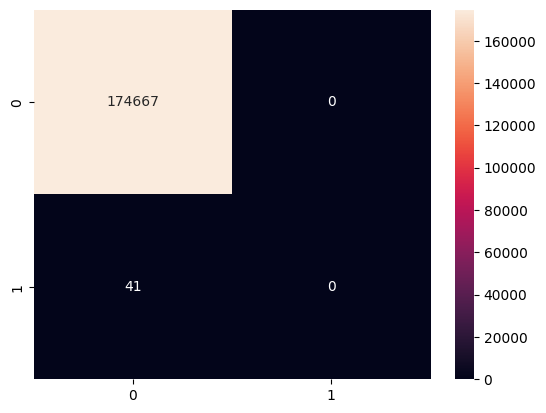

In [30]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
# from sklearn.metrics import accuracy_score

import seaborn as sns # data visualization library 

# split data train 80 % and test 20 %
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) # maintain class balance

# create model instance
bst = XGBClassifier(n_estimators=2, max_depth=4, learning_rate=1, objective='binary:logistic')
clr_rf = bst.fit(x_train, y_train)

pr = precision_score(y_test,bst.predict(x_test))
print('Precision is: ',pr)
rc = recall_score(y_test,bst.predict(x_test))
print('Recall is: ',rc)
cm = confusion_matrix(y_test,bst.predict(x_test))
sns.heatmap(cm,annot=True,fmt="d")
plt.savefig('confusion_mtx.png', bbox_inches='tight')

In [31]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
# find best scored 5 features
select_feature = SelectKBest(chi2, k=5).fit(x_train, y_train)

In [32]:
print('Score list:', select_feature.scores_)
print('Feature list:', x_train.columns)

Score list: [1.23123387e+03 6.84048060e+02 5.39621278e+02 5.52837290e+02
 6.93212140e+04 5.25185916e+04 4.09400204e+04 4.19572562e+04
 6.11278157e+02 3.37615205e+02 2.80394086e+02 1.87804234e+02
 4.80759120e+03 2.82216094e+03 2.25020647e+03 2.45827385e+03
 2.24506950e+01 1.23169947e+02 9.86343367e+01 7.90140441e+01
 1.78807062e+04 8.14944127e+03 6.41227262e+03 7.00058830e+03
 7.29167436e+01 2.59690948e+01 1.49455025e+00 4.07975288e+03
 3.16063201e+03 3.12251260e+04 4.69237101e+02 6.59591878e+04
 3.23395126e+04 3.25872553e+04 5.01292761e-02 3.14930182e+03
 1.39420932e+03 3.42268757e+04 1.67182554e+01 9.43585287e+03
 7.98211143e+03 2.55097383e+04 7.04523868e-02 8.05587194e-02
 6.99480639e+00 2.39389664e+04 9.20831702e+01 2.00857674e+04
 1.31092796e+04 1.07373086e+05 9.42862809e-01 1.42309971e+04
 1.94161810e+04 2.62939171e+04 3.25902603e+03 3.87328904e+04
 1.55575420e+04 2.37558678e+04 3.06579707e+04 2.89048445e+03
 5.84415117e+03 2.51638183e+03 4.25632915e+03 4.75977789e+04
 4.55927652e

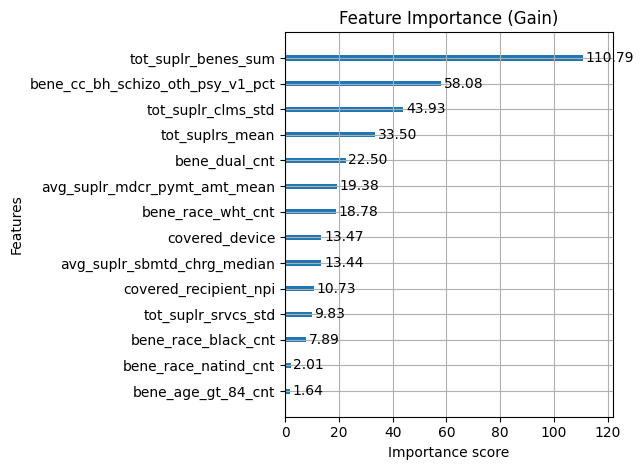

In [33]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
# clf_rf_5 = RandomForestClassifier()      
bst = bst.fit(x_train,y_train)
# importances = bst.feature_importances_
# std = np.std([tree.feature_importances_ for tree in bst.get_booster().get_dump()],
#              axis=0)
# indices = np.argsort(importances)[::-1]

# # Print the feature ranking
# print("Feature ranking:")

# for f in range(x_train.shape[1]):
#     print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

# Plot the feature importances of the forest
ax = plot_importance(bst, importance_type='gain', values_format='{v:.2f}')

ax.set_title('Feature Importance (Gain)')
ax.figure.tight_layout()
plt.savefig('xgboost_feature_importance.png', bbox_inches='tight')
plt.show()

# plt.figure(1, figsize=(14, 13))
# plt.title("Feature importances")
# plt.bar(range(x_train.shape[1]), importances[indices],
#        color="g", yerr=std[indices], align="center")
# plt.xticks(range(x_train.shape[1]), x_train.columns[indices],rotation=90)
# plt.xlim([-1, x_train.shape[1]])
# plt.show()